In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

from sklearn import model_selection
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import roc_curve,auc,roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
DF = pd.read_csv("Bank_Personal_Loan_Modelling-1.csv")

In [3]:
DF.shape

(5000, 14)

- The dataset contains 14 columns and 5000 rows

In [4]:
DF.head(10)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


- The first column is ID column which is Customer ID and nothing to do with the model attriibutes. So, we can drop it.
- We can also see that the columns "Securities Account", "CD Account", "Online", "CreditCard" are binary variables.
- We can see that these columns, "Personal Loan", "Securities Account", "CD Account", "ZIP Code", have space in between the column name.   As a good pratice it is best to have column names without spaces in them. So, we need to rename them.
- Also, we can see that the target column is present in the middle. So, it is best to drop it and append it at the end.

###### Changing the column names

In [5]:
DF.rename(columns={"Personal Loan":"Personal_Loan","Securities Account":"Securities_Account","CD Account":"CD_Account", "ZIP Code":"ZIP_Code"}, inplace = True) 

In [6]:
DF.head()

,ID,Age,Experience,Income,ZIP_Code,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


###### Shifting the Personal Loan column to the end

In [7]:
personal_loan= DF['Personal_Loan']
DF.drop(['Personal_Loan'], axis = 1,inplace = True)
DF['Personal_Loan'] = personal_loan
DF.head()

,ID,Age,Experience,Income,ZIP_Code,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard,Personal_Loan
0,1,25,1,49,91107,4,1.6,1,0,1,0,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,1,0,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,1,0


- The target column, Personal_Loan, is appended at the end.

In [8]:
DF.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP_Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
Personal_Loan         0
dtype: int64

In [9]:
DF.isnull().sum().sum() 

0

- This shows that all the columns in the dataset do not have any null values.
- There are no null values present in the dataset

In [10]:
DF.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP_Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.00,0.0,0.00,1.0


- From the above table, we can see that for "Income" and "Mortage" columns, the max value and 75% value are having a large difference between them. So, we can infer that outliers might be present in "Income" and "Mortgage" columns.

- We can see that minimum value for Experience = -3. As experience cannot be negative, we can assume that there might have been some mistake during data collection or data entry. So, we need to deal with the entries with negative experience values accordingly.


#### Dealing with negative values in experience column

In [11]:
DF[DF['Experience']<0].Experience.value_counts()

-1    33
-2    15
-3     4
Name: Experience, dtype: int64

In [12]:
DF[DF['Experience']<0].Experience.count()

52

- 52 customers have experience as negative. Since, we are not sure of correct values.


In [13]:
exp_negvalue=[-3, -2, -1]

for i in exp_negvalue:
    DF['Experience']=DF['Experience'].replace(exp_negvalue,np.median(DF['Experience']))

In [14]:
DF.Experience.describe()

count    5000.000000
mean       20.327600
std        11.253035
min         0.000000
25%        11.000000
50%        20.000000
75%        30.000000
max        43.000000
Name: Experience, dtype: float64

In [15]:
DF[DF['Experience']<0].Experience.count()

0

In [16]:
DF.groupby(["Personal_Loan"]).count()


,ID,Age,Experience,Income,ZIP_Code,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard
Personal_Loan,,,,,,,,,,,,,
0,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520
1,480,480,480,480,480,480,480,480,480,480,480,480,480


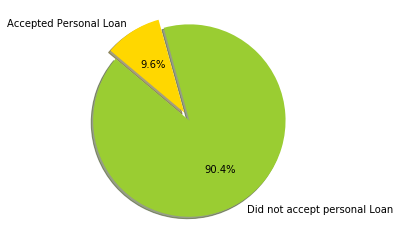

In [17]:
labels = 'Did not accept personal Loan','Accepted Personal Loan' 
data= DF['Personal_Loan'].value_counts()
colors = ['yellowgreen', 'gold']
explode = (0.1, 0)  # explode 1st slice

# Plot
plt.pie(data, explode=explode, labels=labels, colors=colors,autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')
plt.show()

- We can see that in the dataset, 90.4% entries are of customers who have not availed personal loan. 
- Only 9.6% of the accepted the personal loan that was offered to them in the earlier campaign.

In [18]:
DF.dtypes.value_counts()

int64      13
float64     1
dtype: int64

In [19]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP_Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Securities_Account    5000 non-null int64
CD_Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
Personal_Loan         5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


- We can see from here that 13 columns belong to integer data type. Only "CCAvg" column belongs to Float data type

In [20]:
##Identify duplicates records in the data
dupes = DF.duplicated()
sum(dupes)

0

- From here, we can conclude that there are no duplicate values in the dataset

In [21]:
df_ages= pd.cut(x=DF['Age'], bins=[0, 29, 39, 49,59,69])


In [22]:
df_ages.value_counts()

(49, 59]    1334
(39, 49]    1257
(29, 39]    1247
(59, 69]     674
(0, 29]      488
Name: Age, dtype: int64

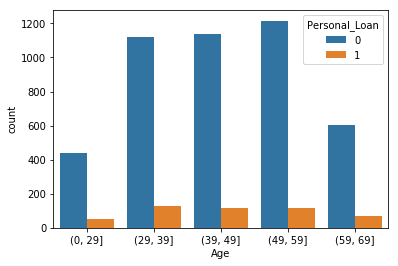

In [23]:
sns.countplot(df_ages,hue=DF['Personal_Loan'])


In [24]:
df_mortgage= pd.cut(x=DF['Mortgage'], bins=[-1,70,150,250,350,450,550,650])


In [25]:
df_mortgage.value_counts()

(-1, 70]      3462
(70, 150]      752
(150, 250]     487
(250, 350]     178
(350, 450]      80
(450, 550]      25
(550, 650]      16
Name: Mortgage, dtype: int64

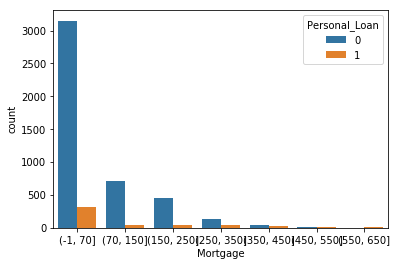

In [26]:
sns.countplot(df_mortgage,hue=DF['Personal_Loan'])


#### To check the prsence of outliers

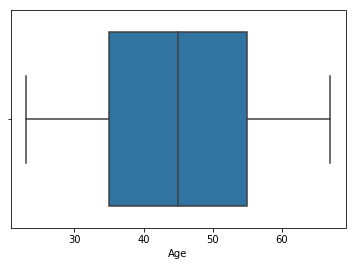

In [27]:
sns.boxplot(x=DF['Age'])   # box plot

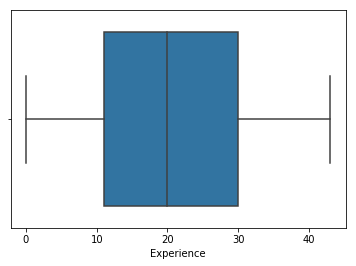

In [28]:
sns.boxplot(x=DF['Experience'])   # box plot

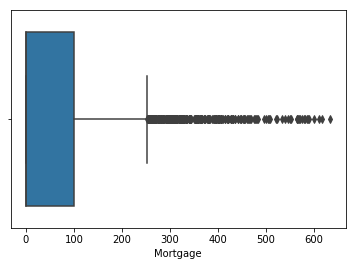

In [29]:
sns.boxplot(x=DF['Mortgage'])   # box plot

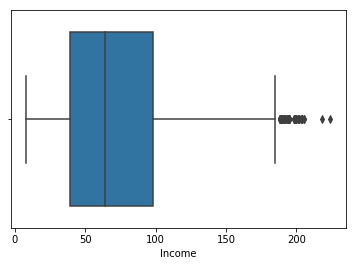

In [30]:
sns.boxplot(x=DF['Income'])   # box plot

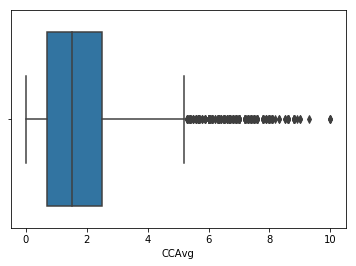

In [31]:
sns.boxplot(x=DF['CCAvg'])   # box plot

- From the above graphs, we can how many outliers are present in each feature of the dataset. Most of the outliers are in    Income, Mortgage, and CCAvg.


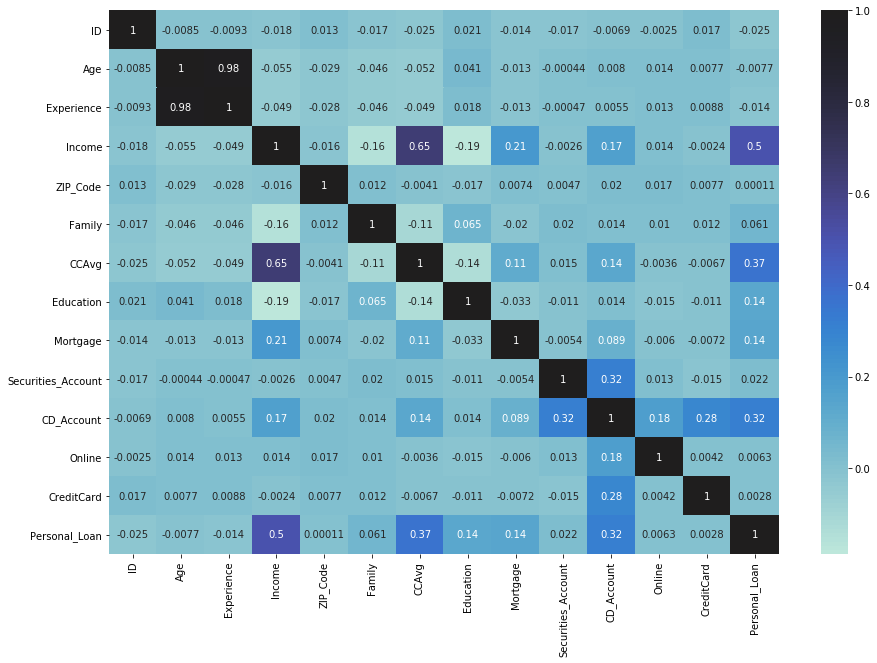

In [32]:
plt.figure(figsize=(15,10))
sns.heatmap(DF.corr(), annot=True,center = 1 )  # heatmap
plt.show()

- We can see here that Age and Experience columns are highly correlated. As some of the values in the Experience are imputed, it is best to drop the Experience column and keep the Age column for our analysis.
- Also, we can see that "Income","CCAvg","CD_Account","Education","Mortgage" are top five features which are highly correlated with our target colum,"Personal_Loan"


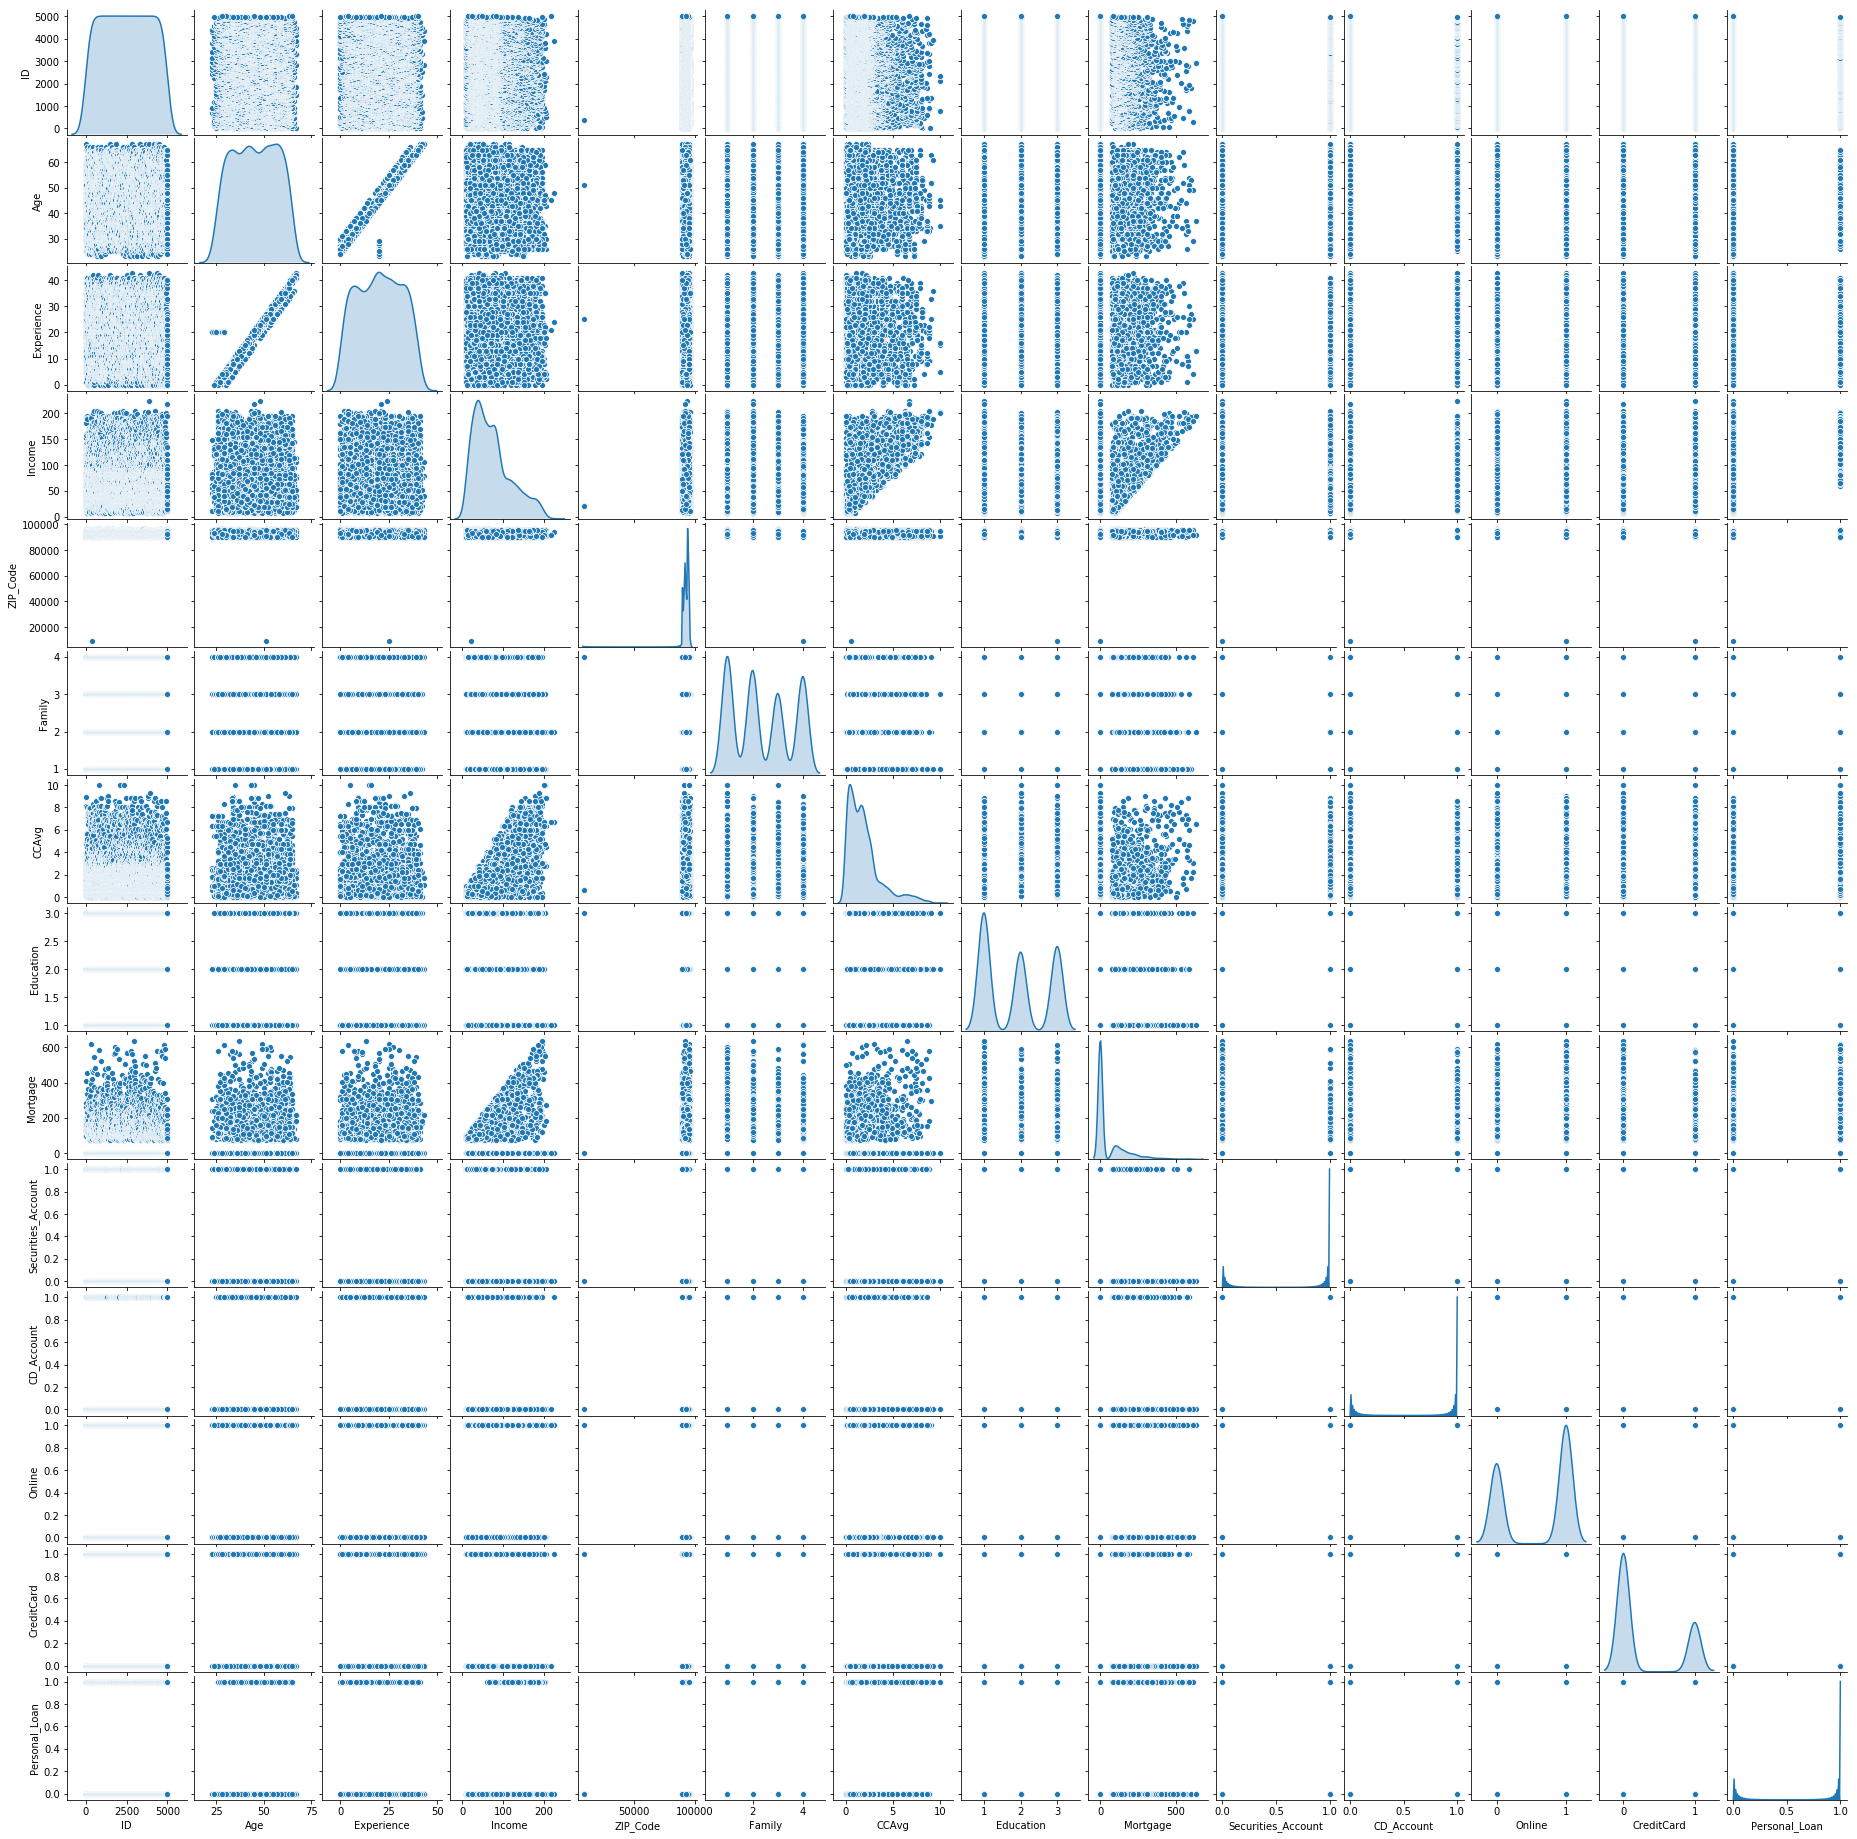

In [33]:
g= sns.pairplot(DF, diag_kind="kde",height =10, aspect=0.6)
g.fig.set_size_inches(25,25)


- Age feature is normally distributed with majority of customers falling between 30 years and 60 years of age. 

- Experience is normally distributed. Mean is almost equal to median. 

- Income is positively skewed. We can confirm this by saying the mean is greater than the median

- CCAvg is also a positively skewed variable and average spending is between 0K to 10K and majority spends less than 2.5K

- Mortgage is also positively skewed. We can see from the box plot and this pair plot as well that majority of the people have low mortgage. 69.2% of the people considered for this study have mortgage less than 70k. Only 0.8% of the people considered for this study have a mortgage value above 450k.

### Kurtosis


Kurtosis describes the shape of a probability distribution. It is a measure of taildedness of the distribution.

Positive Value - denotes heavy tails or more data is distributed around the tails

Negative Value - denotes light tails or less data is distributed around the tails

In [34]:
DF.kurtosis(numeric_only= True)

ID                     -1.200000
Age                    -1.153067
Experience             -1.115685
Income                 -0.044244
ZIP_Code              486.204272
Family                 -1.403586
CCAvg                   2.646706
Education              -1.546116
Mortgage                4.756797
Securities_Account      4.701013
CD_Account             11.633404
Online                 -1.844883
CreditCard             -1.182191
Personal_Loan           5.529589
dtype: float64

### Skewness


Skewness similar to Kurtosis describes the shape of a probability distribution. It is a measure of asymmetry of the distribution.

**Positive Skew** - denotes right tail is longer

**Negative Skew** - denotes left tail is longer

In [35]:
DF.skew(numeric_only= True)

ID                     0.000000
Age                   -0.029341
Experience            -0.014100
Income                 0.841339
ZIP_Code             -12.500221
Family                 0.155221
CCAvg                  1.598443
Education              0.227093
Mortgage               2.104002
Securities_Account     2.588268
CD_Account             3.691714
Online                -0.394785
CreditCard             0.904589
Personal_Loan          2.743607
dtype: float64

- From here we can see that "Age", "Experience", "ZIP Code", "Online" we can see that these columns are negatively skewed.


### Multicollinearity and Variation Inflation Factor (VIF)
**Multicollinearity** - Multicollinearity happens when one or more of the independent variables are strongly correlated with each other. In such scenarios, we should use only one among correlated independent variables.


**VIF** - is an indicator of the existence of multicollinearity.

Let us now perform VIF analysis to remove multicollinearity.

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df=DF.copy()

def calc_vif(df):
    vif = pd.DataFrame()
    vif["variables"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return(vif)

df = df.iloc[:,:-1]
calc_vif(df)

,variables,VIF
0,ID,4.008063
1,Age,354.291538
2,Experience,91.431702
3,Income,6.594357
4,ZIP_Code,120.894026
5,Family,5.523219
6,CCAvg,3.845689
7,Education,6.335952
8,Mortgage,1.376058
9,Securities_Account,1.269238


- We can see here that the ‘Age’, ‘Experience’ and 'ZIP Code' have a high VIF value. It means that they can be predicted by other independent variables in the dataset.
- So, we can go ahead and drop those columns.



In [37]:
X_vif= DF.copy()
X_vif.drop(['Experience', 'ZIP_Code'], axis=1, inplace= True)

In [38]:
X_vif = X_vif.iloc[:,:-1]
calc_vif(X_vif)

,variables,VIF
0,ID,3.667441
1,Age,9.337641
2,Income,6.019456
3,Family,4.601890
4,CCAvg,3.832972
5,Education,5.332252
6,Mortgage,1.372667
7,Securities_Account,1.256073
8,CD_Account,1.383360
9,Online,2.466243


- We can see that after dropping 'Experience', 'ZIP Code' columns, the VIF has significantly gone down for Age column and it has reduced slightly for other columns as well.

In [39]:
DF.shape

(5000, 14)

In [40]:
pd.crosstab(DF['Online'],DF['Personal_Loan'])


Personal_Loan,0,1
Online,,
0,1827,189
1,2693,291


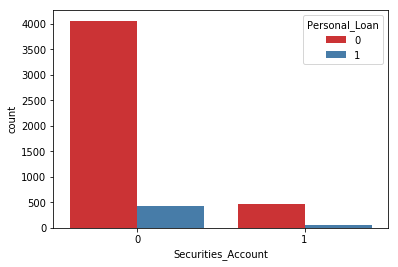

In [41]:
sns.countplot(x="Securities_Account", data=DF,hue="Personal_Loan", palette= 'Set1')


- Customers with Securities account have slightly higher chances of buying the personal loan than the customers with no Securities account



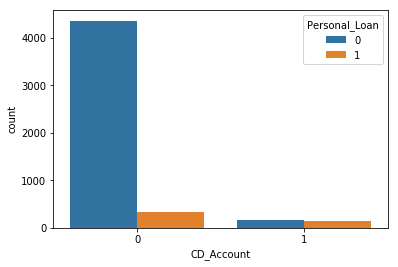

In [42]:
sns.countplot(DF['CD_Account'],hue=DF['Personal_Loan'])


- Here, we can see that most of the people who have CD Account have taken personal loan. Customers with CD account have very high percentage (46.3%) of buying the personal loan than the customers with no CD account (7.2%)



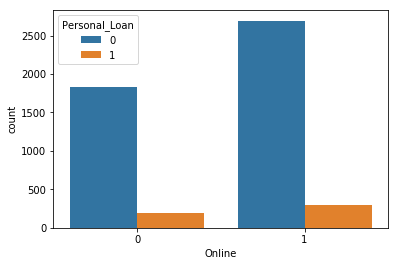

In [43]:
sns.countplot(DF['Online'],hue=DF['Personal_Loan'])


- No such relation can be seen here.

In [44]:
df_income= pd.cut(x=DF['Income'], bins=[-1,50,100,150,200, 250])
df_income.value_counts()


(-1, 50]      1914
(50, 100]     1874
(100, 150]     770
(150, 200]     426
(200, 250]      16
Name: Income, dtype: int64

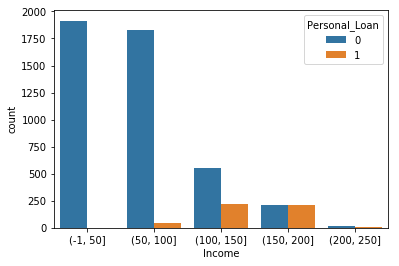

In [45]:
sns.countplot(df_income,hue=DF['Personal_Loan'])


- Here we can see that people with higher income are more likely to take a personal loan when compared to people with low income.

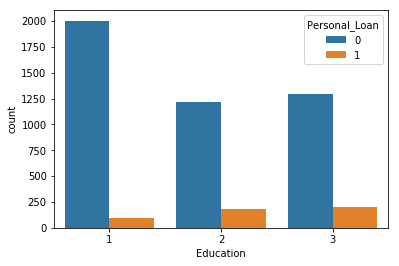

In [46]:
sns.countplot(DF['Education'],hue=DF['Personal_Loan'])


- People belonging to Graduate and Advanced/professional category in education are more likely to take a personal Loan. 
- Very less percent of undergraduate people took a personal loan.

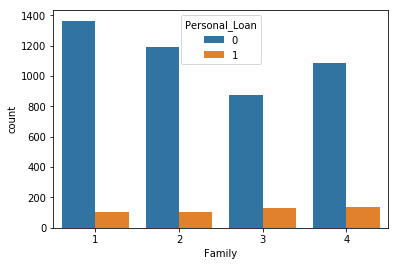

In [47]:
sns.countplot(DF['Family'],hue=DF['Personal_Loan'])

In [48]:
pd.crosstab(DF['Family'], DF['Personal_Loan'])

Personal_Loan,0,1
Family,,
1,1365,107
2,1190,106
3,877,133
4,1088,134


- People with 3 and 4 family members are more likely to avail a personal loan

## HYPOTHESIS TESTING

In [49]:
import scipy.stats as stats


- Let us consider level of significance to be 0.05 for hypothesis testing

##### Does income of a person have any impact on availing personal loan?

- H0:"Income of a person has an impact on availing Personal Loan"
    
    
- Ha:"Income of a person does not have any impact on availing Personal Loan"

In [50]:
Income_PL_Yes=np.array((DF[DF['Personal_Loan']==1]).Income)
Income_PL_No=np.array((DF[DF['Personal_Loan']==0]).Income)

stats.ttest_ind(Income_PL_Yes,Income_PL_No,axis=0)

Ttest_indResult(statistic=41.08533291207552, pvalue=0.0)

- As the P_value = 0.0 which  is less than 0.05. Income of a person has an impact on availing Personal Loan.


##### Does family have any impact on availing personal loan?

- H0:"Family does not have any impact on availing Personal Loan"
    
    
- Ha:"Family has an impact on availing Personal Loan"

In [51]:
Family_PL_Yes=np.array((DF[DF['Personal_Loan']==1]).Family)
Family_PL_No=np.array((DF[DF['Personal_Loan']==0]).Family)

stats.ttest_ind(Income_PL_Yes,Income_PL_No,axis=0)

Ttest_indResult(statistic=41.08533291207552, pvalue=0.0)

- As the P_value = 0.0 which  is less than 0.05. Family has an impact on availing Personal Loan.


In [52]:
## Performing hypothesis testing for ordinal, numerical and binary variables seperately

In [53]:
import statsmodels.api as sm
target_column=DF['Personal_Loan']
DF_num = DF.loc[:,['Income','Mortgage', 'Age','CCAvg']]
DF_num['intercept'] = 1

logit_mod=sm.Logit(target_column,DF_num)
log_mod=logit_mod.fit()
print(log_mod.summary2())

Optimization terminated successfully.
         Current function value: 0.200574
         Iterations 8
                          Results: Logit
Model:              Logit            Pseudo R-squared: 0.366      
Dependent Variable: Personal_Loan    AIC:              2015.7436  
Date:               2020-09-23 17:10 BIC:              2048.3296  
No. Observations:   5000             Log-Likelihood:   -1002.9    
Df Model:           4                LL-Null:          -1581.0    
Df Residuals:       4995             LLR p-value:      4.7422e-249
Converged:          1.0000           Scale:            1.0000     
No. Iterations:     8.0000                                        
-------------------------------------------------------------------
               Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
Income         0.0351    0.0016   22.3127  0.0000   0.0320   0.0382
Mortgage       0.0007    0.0004    1.7566  0.0790

- p -values for Income, CCAvg are less than α=0.05. Therefore, we can say that they are significant in predicting the target column. Age and Mortgage columns has p-value greater than 0.05. It looks like they have very less impact on the target column.


In [54]:
DF_ordinal = DF.loc[:,['Family','Education']]
DF_ordinal['intercept'] = 1

logit_mod=sm.Logit(target_column,DF_ordinal )
log_mod=logit_mod.fit()
print(log_mod.summary())

Optimization terminated successfully.
         Current function value: 0.305406
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          Personal_Loan   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4997
Method:                           MLE   Df Model:                            2
Date:                Wed, 23 Sep 2020   Pseudo R-squ.:                 0.03415
Time:                        17:10:51   Log-Likelihood:                -1527.0
converged:                       True   LL-Null:                       -1581.0
                                        LLR p-value:                 3.575e-24
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Family         0.1623      0.042      3.863      0.000       0.080       0.245
Education      0.5487      0.

- p-values of Family and Education columns are less than 0.05, we can say that both the attributes are significant for predicting the target attribute class


In [55]:
DF_binary = DF.loc[:,['CD_Account','Securities_Account','Online','CreditCard']]
DF_binary['intercept'] = 1

logit_mod=sm.Logit(target_column,DF_binary )
log_mod=logit_mod.fit()
print(log_mod.summary())

Optimization terminated successfully.
         Current function value: 0.273620
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          Personal_Loan   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4995
Method:                           MLE   Df Model:                            4
Date:                Wed, 23 Sep 2020   Pseudo R-squ.:                  0.1347
Time:                        17:10:51   Log-Likelihood:                -1368.1
converged:                       True   LL-Null:                       -1581.0
                                        LLR p-value:                 7.257e-91
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
CD_Account             3.8738      0.206     18.780      0.000       3.470       4.278
Secur

- The p-values for all the columns are less than 0.05, so we can conclude that all the attributes are useful for predicting target column.



### MODEL BUILDING ON UNSCALED DATA

In [56]:
Personal_Loan_DF=DF.copy()


In [57]:
Personal_Loan_DF.shape

(5000, 14)

In [58]:
Personal_Loan_DF.columns


Index(['ID', 'Age', 'Experience', 'Income', 'ZIP_Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online',
       'CreditCard', 'Personal_Loan'],
      dtype='object')

In [59]:
model_list=["Logistic regression", 'KNN','Naive Bayes']

- Here I wanted to show how the model changes from underfit to overfit as we vary the munber of features.
 

# Iteration 1

### Without dropping any columns

In [60]:
X1= Personal_Loan_DF.drop('Personal_Loan', axis=1)
y= Personal_Loan_DF['Personal_Loan']

In [61]:
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.3, random_state=10)


In [62]:
model_f1_score_iter1=[]
model_accuracy_score_iter1=[]

### 1)Logistic Regression



In [63]:
model = LogisticRegression()
model.fit(X1_train, y_train)
y_predict_lr1 = model.predict(X1_test)

coef_df = pd.DataFrame(model.coef_, columns=X1.columns)
coef_df['intercept'] = model.intercept_
print(coef_df)

model_accuracy_lr_iter1= accuracy_score(y_predict_lr1, y_test)
model_accuracy_score_iter1.append(model_accuracy_lr_iter1)

print("Model Accuracy: ")
print(model_accuracy_lr_iter1)


         ID       Age  Experience    Income  ZIP_Code    Family     CCAvg  \
0 -0.000047  0.000095   -0.000364  0.037046 -0.000064  0.000675  0.001218   

   Education  Mortgage  Securities_Account  CD_Account   Online  CreditCard  \
0   0.000879  0.000625            0.000061    0.000299 -0.00002   -0.000003   

   intercept  
0  -0.000004  
Model Accuracy: 
0.902


In [64]:
print(metrics.confusion_matrix(y_test, y_predict_lr1))
print(classification_report(y_test, y_predict_lr1))

[[1304   56]
 [  91   49]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1360
           1       0.47      0.35      0.40       140

   micro avg       0.90      0.90      0.90      1500
   macro avg       0.70      0.65      0.67      1500
weighted avg       0.89      0.90      0.90      1500



### 2) KNN

In [65]:
NNH = KNeighborsClassifier()

NNH.fit(X1_train, y_train)


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=5, p=2,
           weights='uniform')

In [66]:
y_predict_knn1=NNH.predict(X1_test)


In [67]:
knn_accuracy_iter1=accuracy_score(y_test,y_predict_knn1)
model_accuracy_score_iter1.append(knn_accuracy_iter1)
knn_accuracy_iter1

0.908

In [68]:
print(metrics.confusion_matrix(y_test, y_predict_knn1))
print(classification_report(y_test, y_predict_knn1))

[[1356    4]
 [ 134    6]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1360
           1       0.60      0.04      0.08       140

   micro avg       0.91      0.91      0.91      1500
   macro avg       0.76      0.52      0.52      1500
weighted avg       0.88      0.91      0.87      1500



### 3) Naive Bayes

In [69]:
NBmodel = GaussianNB()
NBmodel.fit(X1_train, y_train)
print(NBmodel)

y_predict_nb1 = NBmodel.predict(X1_test)


print(metrics.classification_report(y_test, y_predict_nb1))
print(metrics.confusion_matrix(y_test, y_predict_nb1))

GaussianNB(priors=None, var_smoothing=1e-09)
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      1360
           1       0.43      0.62      0.51       140

   micro avg       0.89      0.89      0.89      1500
   macro avg       0.69      0.77      0.72      1500
weighted avg       0.91      0.89      0.90      1500

[[1243  117]
 [  53   87]]


In [70]:
NB_accuracy_iter1=accuracy_score(y_test,y_predict_nb1)
model_accuracy_score_iter1.append(NB_accuracy_iter1)
NB_accuracy_iter1

0.8866666666666667

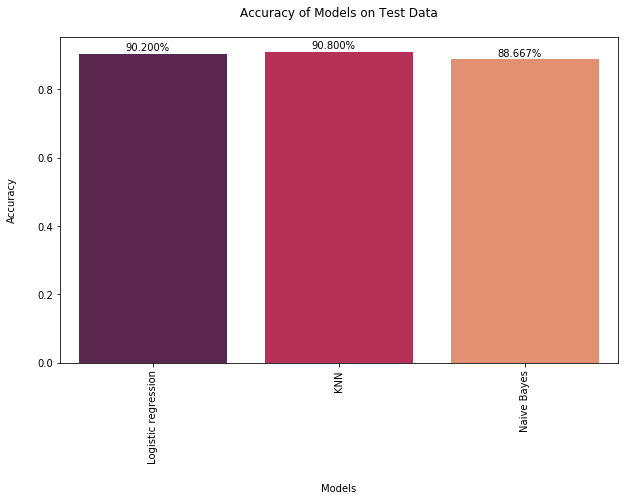

In [71]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(model_list,model_accuracy_score_iter1,palette="rocket")
ax.set_title("Accuracy of Models on Test Data",pad=20)
ax.set_xlabel("Models",labelpad=20)
ax.set_ylabel("Accuracy",labelpad=20)
plt.xticks(rotation=90)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.annotate('{:.3%}'.format(height), (x+0.25, y + height + 0.01))

# Iteration 2

###  Dropping "ID", "Experience" and "ZIP_Code" columns

In [72]:
X2= Personal_Loan_DF.drop(['Personal_Loan',"ID","Experience","ZIP_Code"], axis=1)
y= Personal_Loan_DF['Personal_Loan']

In [73]:

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.30, random_state=2)


In [74]:
model_f1_score_iter2=[]
model_accuracy_score_iter2=[]

### 1) Logistic Regression

In [75]:
model = LogisticRegression()
model.fit(X2_train, y_train)
y_predict_lr2 = model.predict(X2_test)



coef_df = pd.DataFrame(model.coef_, columns=X2.columns)
coef_df['intercept'] = model.intercept_
print(coef_df)


model_accuracy_lr_iter2= accuracy_score(y_predict_lr2, y_test)
model_accuracy_score_iter2.append(model_accuracy_lr_iter2)

print("Model Accuracy: ")
print(model_accuracy_lr_iter2)



print(metrics.confusion_matrix(y_test, y_predict_lr2))
print(classification_report(y_test, y_predict_lr2))

        Age    Income    Family    CCAvg  Education  Mortgage  \
0 -0.018683  0.045995  0.513533  0.06233   1.263189  0.000286   

   Securities_Account  CD_Account    Online  CreditCard  intercept  
0             -0.8654    3.245978 -0.827723   -0.914151  -9.740859  
Model Accuracy: 
0.9353333333333333
[[1336   26]
 [  71   67]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1362
           1       0.72      0.49      0.58       138

   micro avg       0.94      0.94      0.94      1500
   macro avg       0.83      0.73      0.77      1500
weighted avg       0.93      0.94      0.93      1500



### 2) KNN

In [76]:
NNH = KNeighborsClassifier()
NNH.fit(X2_train, y_train)
y_predict_knn2 = NNH.predict(X2_test)


In [77]:
knn_accuracy_iter2=accuracy_score(y_test,y_predict_knn2)
model_accuracy_score_iter2.append(knn_accuracy_iter2)
knn_accuracy_iter2

0.912

In [78]:
print(metrics.confusion_matrix(y_test, y_predict_knn2))
print(classification_report(y_test, y_predict_knn2))

[[1326   36]
 [  96   42]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1362
           1       0.54      0.30      0.39       138

   micro avg       0.91      0.91      0.91      1500
   macro avg       0.74      0.64      0.67      1500
weighted avg       0.90      0.91      0.90      1500



### 3) Naive Bayes

In [79]:
NBmodel = GaussianNB()
NBmodel.fit(X2_train, y_train)
print(NBmodel)

y_predict_nb2 = NBmodel.predict(X2_test)


print(metrics.classification_report(y_test, y_predict_nb2))
print(metrics.confusion_matrix(y_test, y_predict_nb2))


GaussianNB(priors=None, var_smoothing=1e-09)
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1362
           1       0.42      0.51      0.46       138

   micro avg       0.89      0.89      0.89      1500
   macro avg       0.68      0.72      0.70      1500
weighted avg       0.90      0.89      0.89      1500

[[1264   98]
 [  67   71]]


In [80]:
NB_accuracy_iter2=accuracy_score(y_test,y_predict_nb2)
model_accuracy_score_iter2.append(NB_accuracy_iter2)
NB_accuracy_iter2

0.89

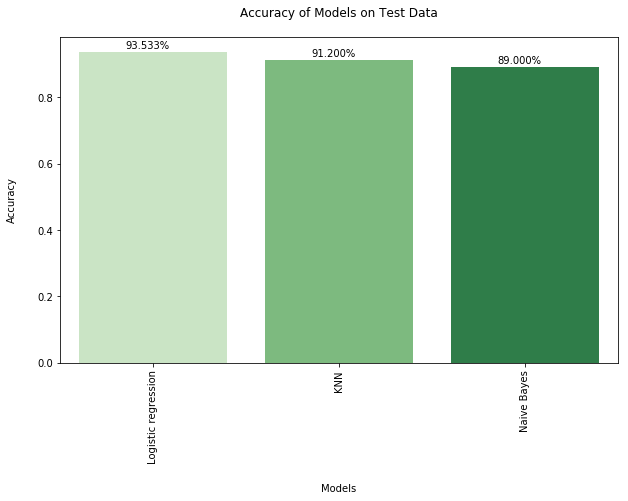

In [81]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(model_list,model_accuracy_score_iter2,palette="Greens")
ax.set_title("Accuracy of Models on Test Data",pad=20)
ax.set_xlabel("Models",labelpad=20)
ax.set_ylabel("Accuracy",labelpad=20)
plt.xticks(rotation=90)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.annotate('{:.3%}'.format(height), (x+0.25, y + height + 0.01))

# Iteration 3

### Dropping "ID", "Experience" , "ZIP_Code" , "Family", "Securities_Account", "Online", "CreditCard", "Age" columns

In [82]:
X3= Personal_Loan_DF.drop(['Personal_Loan',"ID","Experience","ZIP_Code", 'Family', 'Securities_Account',
       'Online', 'CreditCard', 'Age'], axis=1)
y= Personal_Loan_DF['Personal_Loan']

X3_train, X3_test, y_train, y_test = train_test_split(X3, y, test_size=0.30, random_state=1)

In [83]:
model_f1_score_iter3=[]
model_accuracy_score_iter3=[]

### 1) Logistic Regression

In [84]:
model = LogisticRegression()
model.fit(X3_train, y_train)
y_predict_lr3 = model.predict(X3_test)



coef_df = pd.DataFrame(model.coef_, columns=X3.columns)
coef_df['intercept'] = model.intercept_
print(coef_df)


model_accuracy_lr_iter3= accuracy_score(y_predict_lr3, y_test)
model_accuracy_score_iter3.append(model_accuracy_lr_iter3)


print("Model Accuracy: ")
print(model_accuracy_lr_iter3)
print("Confusion matrix:")
print(metrics.confusion_matrix(y_test, y_predict_lr3))
print(classification_report(y_test, y_predict_lr3))

     Income     CCAvg  Education  Mortgage  CD_Account  intercept
0  0.038943  0.131367   1.307706   0.00068    1.976198   -9.49937
Model Accuracy: 
0.9446666666666667
Confusion matrix:
[[1340   11]
 [  72   77]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1351
           1       0.88      0.52      0.65       149

   micro avg       0.94      0.94      0.94      1500
   macro avg       0.91      0.75      0.81      1500
weighted avg       0.94      0.94      0.94      1500



### 2) KNN

In [85]:
NNH = KNeighborsClassifier()
NNH.fit(X3_train, y_train)
y_predict_knn3 = NNH.predict(X3_test)

In [86]:
knn_accuracy_iter3=accuracy_score(y_test,y_predict_knn3)
model_accuracy_score_iter3.append(knn_accuracy_iter3)
knn_accuracy_iter3

0.9133333333333333

In [87]:
print(metrics.confusion_matrix(y_test, y_predict_knn3))
print(classification_report(y_test, y_predict_knn3))

[[1312   39]
 [  91   58]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1351
           1       0.60      0.39      0.47       149

   micro avg       0.91      0.91      0.91      1500
   macro avg       0.77      0.68      0.71      1500
weighted avg       0.90      0.91      0.90      1500



### 3) Naive Bayes

In [88]:
NBmodel = GaussianNB()
NBmodel.fit(X3_train, y_train)
print(NBmodel)

y_predict_nb3 = NBmodel.predict(X3_test)


print(metrics.classification_report(y_test, y_predict_nb3))
print(metrics.confusion_matrix(y_test, y_predict_nb3))

GaussianNB(priors=None, var_smoothing=1e-09)
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1351
           1       0.40      0.56      0.47       149

   micro avg       0.87      0.87      0.87      1500
   macro avg       0.67      0.74      0.70      1500
weighted avg       0.90      0.87      0.88      1500

[[1225  126]
 [  65   84]]


In [89]:
NB_accuracy_iter3=accuracy_score(y_test,y_predict_nb3)
model_accuracy_score_iter3.append(NB_accuracy_iter3)
NB_accuracy_iter3

0.8726666666666667

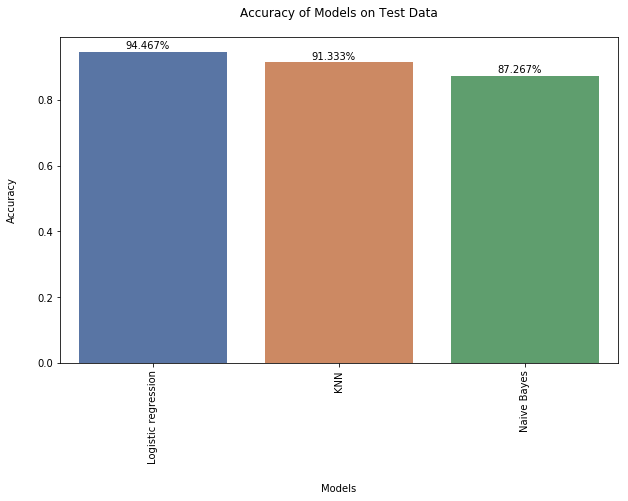

In [90]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(model_list,model_accuracy_score_iter3,palette="deep")
ax.set_title("Accuracy of Models on Test Data",pad=20)
ax.set_xlabel("Models",labelpad=20)
ax.set_ylabel("Accuracy",labelpad=20)
plt.xticks(rotation=90)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.annotate('{:.3%}'.format(height), (x+0.25, y + height + 0.01))


# Iteration 4

### Dropping "ID","Experience","ZIP_Code", 'Family', 'Securities_Account','Online', 'CreditCard', 'Age', 'Education', 'Mortgage' columns

In [91]:
X4= Personal_Loan_DF.drop(['Personal_Loan',"ID","Experience","ZIP_Code", 'Family', 'Securities_Account',
       'Online', 'CreditCard', 'Age', 'Education', 'Mortgage'], axis=1)
y= Personal_Loan_DF['Personal_Loan']

In [92]:
X4_train, X4_test, y_train, y_test = train_test_split(X4, y, test_size=0.40, random_state=1)

In [93]:
model_f1_score_iter4=[]
model_accuracy_score_iter4=[]

### 1) Logistic Regression

In [94]:
model = LogisticRegression()
model.fit(X4_train, y_train)
y_predict_lr4 = model.predict(X4_test)



coef_df = pd.DataFrame(model.coef_, columns=X4.columns)
coef_df['intercept'] = model.intercept_
print(coef_df)


model_accuracy_lr_iter4= accuracy_score(y_predict_lr4, y_test)
model_accuracy_score_iter4.append(model_accuracy_lr_iter4)

print("Model Accuracy: ")
print(model_accuracy_lr_iter4)
print(metrics.confusion_matrix(y_test, y_predict_lr4))
print(classification_report(y_test, y_predict_lr4))

     Income     CCAvg  CD_Account  intercept
0  0.030395  0.103241    2.068538  -5.897298
Model Accuracy: 
0.918
[[1773   34]
 [ 130   63]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1807
           1       0.65      0.33      0.43       193

   micro avg       0.92      0.92      0.92      2000
   macro avg       0.79      0.65      0.70      2000
weighted avg       0.90      0.92      0.91      2000



### 2) KNN

In [95]:
NNH = KNeighborsClassifier()
NNH.fit(X4_train, y_train)
y_predict_knn4 = NNH.predict(X4_test)

In [96]:
knn_accuracy_iter4=accuracy_score(y_test,y_predict_knn4)
model_accuracy_score_iter4.append(knn_accuracy_iter4)
knn_accuracy_iter4

0.904

In [97]:
print(metrics.confusion_matrix(y_test, y_predict_knn4))
print(classification_report(y_test, y_predict_knn4))

[[1742   65]
 [ 127   66]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1807
           1       0.50      0.34      0.41       193

   micro avg       0.90      0.90      0.90      2000
   macro avg       0.72      0.65      0.68      2000
weighted avg       0.89      0.90      0.90      2000



### 3) Naive Bayes

In [98]:
NBmodel = GaussianNB()
NBmodel.fit(X4_train, y_train)
print(NBmodel)

y_predict_nb4 = NBmodel.predict(X4_test)


print(metrics.classification_report(y_test, y_predict_nb4))
print(metrics.confusion_matrix(y_test, y_predict_nb4))

GaussianNB(priors=None, var_smoothing=1e-09)
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1807
           1       0.39      0.53      0.45       193

   micro avg       0.87      0.87      0.87      2000
   macro avg       0.67      0.72      0.69      2000
weighted avg       0.89      0.87      0.88      2000

[[1645  162]
 [  91  102]]


In [99]:
NB_accuracy_iter4=accuracy_score(y_test,y_predict_nb4)
model_accuracy_score_iter4.append(NB_accuracy_iter4)
NB_accuracy_iter4

0.8735

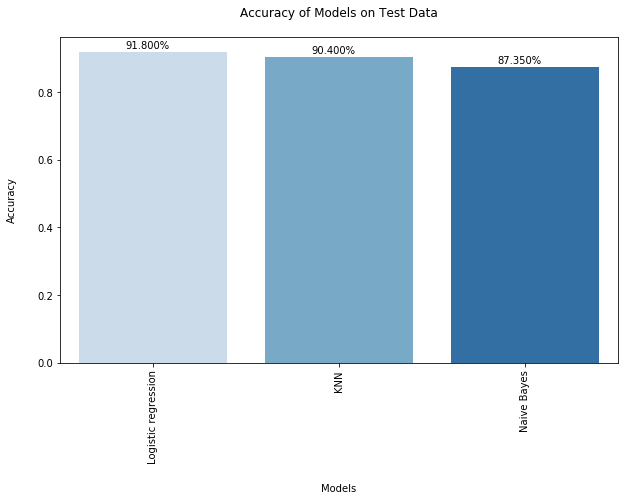

In [100]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(model_list,model_accuracy_score_iter4,palette="Blues")
ax.set_title("Accuracy of Models on Test Data",pad=20)
ax.set_xlabel("Models",labelpad=20)
ax.set_ylabel("Accuracy",labelpad=20)
plt.xticks(rotation=90)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    ax.annotate('{:.3%}'.format(height), (x+0.25, y + height + 0.01))

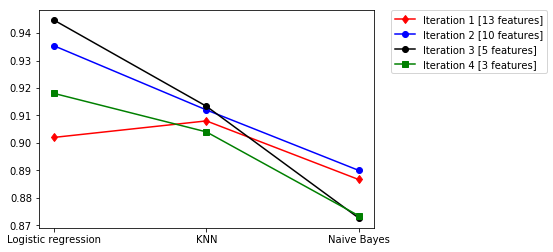

In [101]:
plt.plot(model_list,model_accuracy_score_iter1,'r-d', label='Iteration 1 [13 features]')
plt.plot(model_list,model_accuracy_score_iter2,'b-o', label='Iteration 2 [10 features]')
plt.plot(model_list,model_accuracy_score_iter3, 'k-o',label='Iteration 3 [5 features]')
plt.plot(model_list,model_accuracy_score_iter4,'g-s', label='Iteration 4 [3 features]')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

- In Iteration 4, we have used only 3 features,'Income', 'CCAvg', 'CD_Account', to build the model. We can see that the models are underfit.

- As we started adding more features in Iteration 3, we can see that the Logistic regression and KNN models are tending towards good fit. We can see a significant increase in the Accuracy of these two models.

- In Iteration 2, we can observe that the accuracy of Naive Bayes Model has increased significantly.

- But, we can see that as we added more and more features in Iteration 1, we can see that the model tends to overfit. This can be observed in the significant reduction in accuracy(as compared to Iteration 2).

### MODEL BUILDING ON SCALED DATA

In [102]:
sc=StandardScaler()

In [103]:
X= Personal_Loan_DF.drop(['Personal_Loan',"ID","ZIP_Code","Experience","Age","Mortgage"], axis=1)
y= Personal_Loan_DF['Personal_Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

scaledX_train = sc.fit_transform(X_train)
scaledX_test = sc.transform(X_test)


In [104]:
X.columns

Index(['Income', 'Family', 'CCAvg', 'Education', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='object')

#### Logistic Regression

In [105]:
model = LogisticRegression()
model.fit(scaledX_train, y_train)
y_predict_lr = model.predict(scaledX_test)



coef_df = pd.DataFrame(model.coef_, columns=X.columns)
coef_df['intercept'] = model.intercept_
print(coef_df)


model_accuracy_lr= accuracy_score(y_predict_lr, y_test)

print("Model Accuracy: ")
print(model_accuracy_lr)
print(classification_report(y_test, y_predict_lr))

     Income    Family     CCAvg  Education  Securities_Account  CD_Account  \
0  2.332802  0.777682  0.281066   1.339201           -0.341969    0.892132   

     Online  CreditCard  intercept  
0 -0.287822   -0.504189  -4.556043  
Model Accuracy: 
0.948
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1351
           1       0.84      0.59      0.69       149

   micro avg       0.95      0.95      0.95      1500
   macro avg       0.90      0.79      0.83      1500
weighted avg       0.94      0.95      0.94      1500



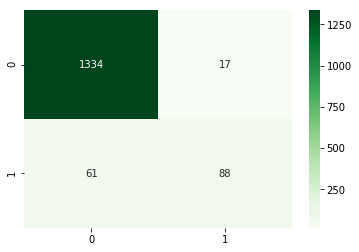

In [106]:
sns.heatmap(confusion_matrix(y_test,y_predict_lr),annot=True,fmt='',cmap='Greens')


- We can see that although accuracy is good, f1-score is low in this case. Also, recall value is low (0.59) for class 1.

- Recall value of 59% means, out of all the customers who would actually buy the loan, only 59% were correctly predicted to be positive (would buy the personal loan) thus bank is missing on 41% of potential customers.

- Precision value of 84% means that out of all positively predicted customers,i.e., Customers who would buy the personal loan,  84% were correctly predicted.

#### KNN

In [107]:
NNH = KNeighborsClassifier(n_neighbors=5)
                          
NNH.fit(scaledX_train, y_train)
y_predicted_knn = NNH.predict(scaledX_test)

In [108]:
knn_accuracy=accuracy_score(y_test,y_predicted_knn)
knn_accuracy

0.968

In [109]:
print(metrics.confusion_matrix(y_test, y_predicted_knn))
print(classification_report(y_test, y_predicted_knn))

[[1345    6]
 [  42  107]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1351
           1       0.95      0.72      0.82       149

   micro avg       0.97      0.97      0.97      1500
   macro avg       0.96      0.86      0.90      1500
weighted avg       0.97      0.97      0.97      1500



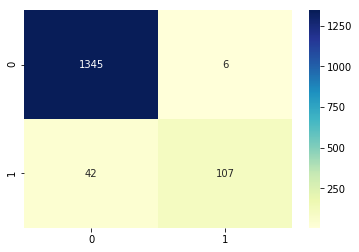

In [110]:
sns.heatmap(confusion_matrix(y_test,y_predicted_knn),annot=True,fmt='',cmap='YlGnBu')


- After scaling the data, we can see that there is a significant increase in the accuracy of KNN model. We can see that the recall of class 1 has increased significantly to 72%. Precision of class 1 is higher for this model as compared to Logistic Regression.


#### Naive Bayes

In [111]:
NBmodel = GaussianNB()
NBmodel.fit(scaledX_train, y_train)
print(NBmodel)

y_predicted_nb = NBmodel.predict(scaledX_test)


print(classification_report(y_test, y_predicted_nb))


GaussianNB(priors=None, var_smoothing=1e-09)
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      1351
           1       0.44      0.55      0.49       149

   micro avg       0.89      0.89      0.89      1500
   macro avg       0.70      0.74      0.71      1500
weighted avg       0.90      0.89      0.89      1500



In [112]:
NB_accuracy=accuracy_score(y_test,y_predicted_nb)
NB_accuracy

0.8866666666666667

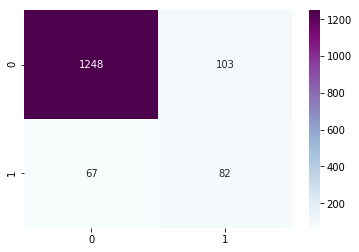

In [113]:
sns.heatmap(confusion_matrix(y_test,y_predicted_nb),annot=True,fmt='',cmap='BuPu')


- We can see that the accuracy of Naive Bayes model is slightly less than logistic regression model. The recall has also reduced significantly here. Out of all the three models, we can see that the F1 score, accuracy, precision and recall are low for Naive Bayes model.


-------------------------------------------------------------------------------------------------------------------------------

##### KNN: How training and testing accuracies vary with n-neighbors?

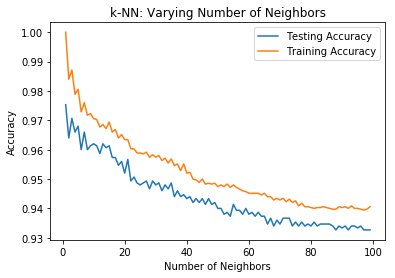

In [114]:
neighbors = np.arange(1, 100)
train_accuracy_plot = np.empty(len(neighbors))
test_accuracy_plot = np.empty(len(neighbors))
for i, k in enumerate(neighbors):
    sc=StandardScaler()
    scaledX_train = sc.fit_transform(X_train)
    scaledX_test = sc.transform(X_test)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(scaledX_train,y_train)
    train_accuracy_plot[i] = knn.score(scaledX_train,y_train)
    test_accuracy_plot[i] = knn.score(scaledX_test,y_test) 
plt.title('k-NN: Varying Number of Neighbors')
plt.plot(neighbors, test_accuracy_plot, label = 'Testing Accuracy')
plt.plot(neighbors, train_accuracy_plot, label = 'Training Accuracy')
plt.legend()
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.show()

- We can see that both the training and testing accuracies are reducing significantly when we increase the number of N neighbors.

##### ROC curve 

Area under the curve[Logistic_Regression]:  0.7890103775975043
Area under the curve[KNN]:  0.8568398253344527
Area under the curve[Naive_Bayes]:  0.7370478740579933


Text(0, 0.5, 'True Positive rate')

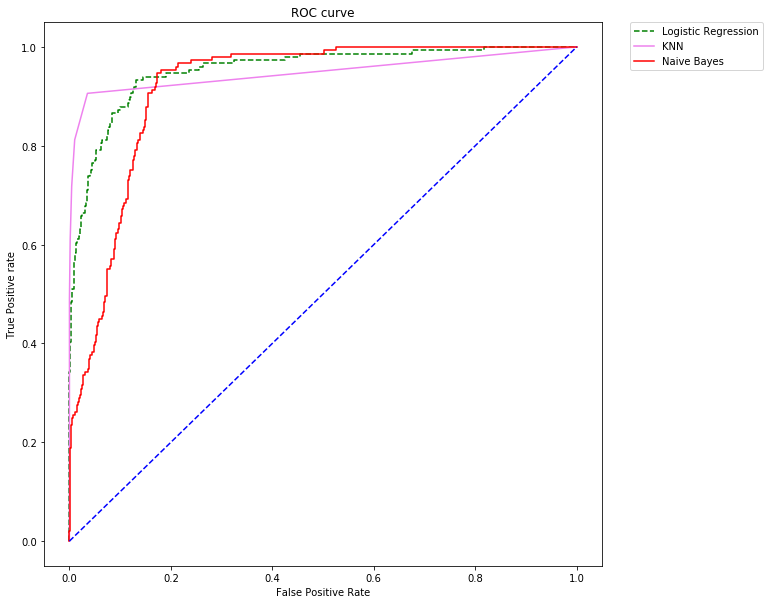

In [115]:

Logistic_Regression_pp=model.predict_proba(scaledX_test)
KNN_pp=NNH.predict_proba(scaledX_test)
Naive_Bayes_pp=NBmodel.predict_proba(scaledX_test)

fpr_lr, tpr_lr, thresh_lr = roc_curve(y_test,Logistic_Regression_pp[:,1] )
fpr_knn,tpr_knn,thresh_knn=roc_curve(y_test,KNN_pp[:,1])
fpr_nb,tpr_nb,thresh_nb=roc_curve(y_test,Naive_Bayes_pp[:,1])

plt.figure(figsize=(10,10))

plt.plot(fpr_lr,tpr_lr,linestyle='--',color='Green', label='Logistic Regression')
plt.plot(fpr_knn,tpr_knn,linestyle='solid',color='violet',label='KNN')
plt.plot(fpr_nb,tpr_nb,linestyle='solid',color='red', label='Naive Bayes')
plt.plot([0, 1], [0, 1],'b--')


model_roc_auc_lr = roc_auc_score(y_test, y_predict_lr)
model_roc_auc_knn = roc_auc_score(y_test, y_predicted_knn)          
model_roc_auc_nb = roc_auc_score(y_test, y_predicted_nb)          

print ("Area under the curve[Logistic_Regression]: ", model_roc_auc_lr)
print ("Area under the curve[KNN]: ", model_roc_auc_knn)
print ("Area under the curve[Naive_Bayes]: ", model_roc_auc_nb)



plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')

- ROC curve is plotted with True Positive Rate(TPR) against the False Positive Rate(FPR) where TPR is on y-axis and FPR is on the x-axis.

- The Pink line shows that KNN model on the data covers more region compared to Logistic Regression and Naive Bayes models. It covers almost 86% of area under the curve.


###### Conclusion: Out of all the three models, we can see that KNN has better accuracy, F1-score, precision and recall as compared to other models.